In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET_PATH = "/Users/joshmacbook/python_projects/OAD/Data/in Use/oad_top10pct_dataset_2024_2025.csv"
ODDS_PATH = "/Users/joshmacbook/python_projects/OAD/Data/in Use/Odds_and_Results.xlsx"

df = pd.read_csv(DATASET_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Rows: 4314
Columns: 16


,dg_id,z_sg_recent,z_ev_current,z_ytd,z_history,course_fit_score,pattern_score_winner,pattern_score_top5,finish_num,field_size,top10_cutoff,is_top10pct,year,event_id,event_name,schedule_event_date
0,13562,0.850293,1.000000,0.0,0.922258,0.262852,4,5,30.0,81,9,False,2024,6,Sony Open in Hawaii,2024-01-14
1,17576,0.885687,0.665999,0.0,0.812934,0.971029,4,5,57.0,81,9,False,2024,6,Sony Open in Hawaii,2024-01-14
2,14796,0.957288,0.587410,0.0,0.000000,1.419681,5,5,13.0,81,9,False,2024,6,Sony Open in Hawaii,2024-01-14
3,8825,0.946251,0.587410,0.4,0.806945,-0.111471,7,7,18.0,81,9,False,2024,6,Sony Open in Hawaii,2024-01-14
4,14578,0.931533,0.475141,0.0,0.786608,-0.396368,7,6,4.0,81,9,True,2024,6,Sony Open in Hawaii,2024-01-14


In [2]:
if "is_top10pct" not in df.columns:
    raise ValueError("Expected column is_top10pct not found.")

BASELINE = df["is_top10pct"].mean()
print("Baseline top10pct rate:", BASELINE)

# Verify required keys exist
for c in ["year", "event_id"]:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

df[["year", "event_id", "is_top10pct"]].head()

Baseline top10pct rate: 0.12471024571163654


,year,event_id,is_top10pct
0,2024,6,False
1,2024,6,False
2,2024,6,False
3,2024,6,False
4,2024,6,True


In [5]:
if "Event_Tier" not in df.columns:
    odds = pd.read_excel(ODDS_PATH)

    # Use the tier column that exists in your odds file
    tier_col = None
    for cand in ["Event_Tier", "event_tier", "EVENT_TIER"]:
        if cand in odds.columns:
            tier_col = cand
            break
    if tier_col is None:
        raise ValueError(f"No tier column found in Odds file. Available: {list(odds.columns)}")

    event_tiers = (
        odds[["year", "event_id", tier_col]]
        .dropna(subset=["year", "event_id", tier_col])
        .drop_duplicates(subset=["year", "event_id"])
        .rename(columns={tier_col: "Event_Tier"})
    )

    event_tiers["year"] = pd.to_numeric(event_tiers["year"], errors="coerce")
    event_tiers["event_id"] = pd.to_numeric(event_tiers["event_id"], errors="coerce")

    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["event_id"] = pd.to_numeric(df["event_id"], errors="coerce")

    df = df.merge(event_tiers, on=["year", "event_id"], how="left")

print(df["Event_Tier"].value_counts(dropna=False))

Event_Tier
REGULAR      2485
SIGNATURE    1274
MAJOR         555
Name: count, dtype: int64


In [6]:
df["event_tier"] = df["Event_Tier"].astype(str).str.strip().str.lower()

# Optional: normalize synonyms if your file uses different strings
# Example:
# df["event_tier"] = df["event_tier"].replace({"majors": "major", "sig": "signature"})

print(df["event_tier"].value_counts(dropna=False))

event_tier
regular      2485
signature    1274
major         555
Name: count, dtype: int64


In [8]:
print("Checking available columns...")

# Basic required identifiers
for c in ["year", "event_id", "is_top10pct"]:
    if c not in df.columns:
        raise ValueError(f"Dataset missing required column: {c}")

# Make sure numeric where needed
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["event_id"] = pd.to_numeric(df["event_id"], errors="coerce")
df["is_top10pct"] = pd.to_numeric(df["is_top10pct"], errors="coerce").fillna(0).astype(int)

# What columns do we have that look like score/components?
candidate_cols = [c for c in df.columns if any(k in c.lower() for k in ["oad", "score", "z_", "ev_", "sg_", "history", "course_fit"])]
print("Candidate columns:", candidate_cols)

# --- Define v1 score column ---
# Priority order:
# 1) existing oad_score
# 2) existing oad_score_v1
# 3) existing model_score
# 4) fallback: build a simple v1 score from components if possible
if "oad_score" in df.columns:
    df["oad_score_v1"] = pd.to_numeric(df["oad_score"], errors="coerce")
    print("Using existing column: oad_score as v1")
elif "oad_score_v1" in df.columns:
    df["oad_score_v1"] = pd.to_numeric(df["oad_score_v1"], errors="coerce")
    print("Using existing column: oad_score_v1 as v1")
elif "model_score" in df.columns:
    df["oad_score_v1"] = pd.to_numeric(df["model_score"], errors="coerce")
    print("Using existing column: model_score as v1")
else:
    print("No oad_score found. Building a fallback v1 from available columns...")

    # Try to build a v1 using common fields that usually exist in your exported table
    # We will min-max normalize within each event to avoid field-strength issues.

    def event_minmax(s):
        s = pd.to_numeric(s, errors="coerce")
        if s.max() > s.min():
            return (s - s.min()) / (s.max() - s.min())
        return 0.0

    # Candidate raw components (use what exists)
    # These names match your weekly_view outputs often; adjust not needed—code checks existence.
    comp_map = {
        "sg_recent_raw": ["z_sg_recent", "sg_total_L12", "sg_total_L24", "sg_total_L40", "sg_recent"],
        "ev_raw": ["z_ev_current", "ev_current_adj", "ev_current", "decimal_odds"],
        "ytd_raw": ["z_ytd", "ytd_made_cut_pct", "ytd_top10", "ytd_avg_sg_total", "ytd_starts"],
        "hist_raw": ["z_history", "made_cut_pct_event", "top10_event", "wins_event", "avg_sg_total_event", "starts_event"],
        "fit_raw": ["course_fit_score", "course_fit_norm"],
    }

    chosen = {}
    for k, candidates in comp_map.items():
        for c in candidates:
            if c in df.columns:
                chosen[k] = c
                break

    print("Chosen fallback components:", chosen)

    # Build normalized per-event versions for scoring
    for k, col in chosen.items():
        df[k] = df.groupby(["year", "event_id"])[col].transform(event_minmax)

    # Fallback v1 weights (close to your original structure, but robust)
    # If a component is missing, it just contributes 0
    df["oad_score_v1"] = (
        0.40 * df.get("sg_recent_raw", 0.0) +
        0.15 * df.get("ev_raw", 0.0) +
        0.20 * df.get("ytd_raw", 0.0) +
        0.20 * df.get("hist_raw", 0.0) +
        0.05 * df.get("fit_raw", 0.0)
    )

# Make sure v1 is numeric
df["oad_score_v1"] = pd.to_numeric(df["oad_score_v1"], errors="coerce")

print(df["oad_score_v1"].describe())

Checking available columns...
Candidate columns: ['z_sg_recent', 'z_ev_current', 'z_ytd', 'z_history', 'course_fit_score', 'pattern_score_winner', 'pattern_score_top5']
No oad_score found. Building a fallback v1 from available columns...
Chosen fallback components: {'sg_recent_raw': 'z_sg_recent', 'ev_raw': 'z_ev_current', 'ytd_raw': 'z_ytd', 'hist_raw': 'z_history', 'fit_raw': 'course_fit_score'}
count    3748.000000
mean        0.422127
std         0.148930
min         0.000000
25%         0.324055
50%         0.410682
75%         0.506679
max         0.994831
Name: oad_score_v1, dtype: float64


In [10]:
# Ensure course_fit exists
if "course_fit_score" not in df.columns:
    df["course_fit_score"] = 0.0

# Normalize course fit within each event (0-1)
df["course_fit_norm"] = (
    df.groupby(["year", "event_id"])["course_fit_score"]
      .transform(lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0.0)
)

def compute_oad_score_v2(row):
    tier = str(row["event_tier"]).lower()

    base = row.get("oad_score_v1", np.nan)
    fit  = row.get("course_fit_norm", 0.0)

    if pd.isna(base):
        base = 0.0

    if tier == "major":
        return base * 1.05 + 0.03 * fit
    if tier == "signature":
        return base * 1.00 + 0.05 * fit
    # regular (hardest)
    return base * 0.97 + 0.02 * fit

# ✅ actually create the column
df["oad_score_v2"] = df.apply(compute_oad_score_v2, axis=1)

# then coerce
df["oad_score_v2"] = pd.to_numeric(df["oad_score_v2"], errors="coerce")

df[["oad_score_v1", "oad_score_v2"]].describe()

,oad_score_v1,oad_score_v2
count,3748.000000,3968.000000
mean,0.422127,0.406935
std,0.148930,0.174403
min,0.000000,0.000000
25%,0.324055,0.313752
50%,0.410682,0.409396
75%,0.506679,0.511060
max,0.994831,1.029426


In [11]:
BASELINE = df["is_top10pct"].mean()

def decile_lift(df_in, score_col):
    if df_in is None or df_in.empty:
        return pd.DataFrame(columns=["decile", "avg_top10pct_rate", "lift_vs_baseline", "n_events"])

    rows = []
    events_used = 0

    for (yr, eid), g in df_in.groupby(["year", "event_id"]):
        g = g.dropna(subset=[score_col, "is_top10pct"]).copy()
        if len(g) < 10:
            continue

        g["decile"] = pd.qcut(
            g[score_col].rank(method="first"),
            10,
            labels=False,
            duplicates="drop"
        )

        # If qcut collapses too hard, skip
        if g["decile"].nunique() < 5:
            continue

        events_used += 1

        tmp = g.groupby("decile")["is_top10pct"].mean().reset_index()
        tmp["event_key"] = f"{int(yr)}_{int(eid)}"
        rows.append(tmp)

    if not rows:
        return pd.DataFrame(columns=["decile", "avg_top10pct_rate", "lift_vs_baseline", "n_events"])

    all_rows = pd.concat(rows, ignore_index=True)

    out = (
        all_rows.groupby("decile", as_index=False)
        .agg(avg_top10pct_rate=("is_top10pct", "mean"))
        .sort_values("decile", ascending=False)
    )
    out["lift_vs_baseline"] = out["avg_top10pct_rate"] / BASELINE
    out["n_events"] = events_used
    return out

In [12]:
d1 = decile_lift(df, "oad_score_v1")
d2 = decile_lift(df, "oad_score_v2")

print("Baseline:", BASELINE)

print("\nV1 overall:")
display(d1)

print("\nV2 overall:")
display(d2)

Baseline: 0.12471024571163654

V1 overall:


,decile,avg_top10pct_rate,lift_vs_baseline,n_events
9,9,0.342377,2.745381,62
8,8,0.210445,1.687475,62
7,7,0.163306,1.309487,62
6,6,0.180069,1.443900,62
5,5,0.108602,0.870836,62
4,4,0.094028,0.753975,62
3,3,0.086233,0.691465,62
2,2,0.042435,0.340266,62
1,1,0.055108,0.441885,62
0,0,0.037366,0.299619,62



V2 overall:


,decile,avg_top10pct_rate,lift_vs_baseline,n_events
9,9,0.343126,2.751385,62
8,8,0.200941,1.611262,62
7,7,0.162462,1.302713,62
6,6,0.157623,1.263913,62
5,5,0.114535,0.918412,62
4,4,0.095584,0.766446,62
3,3,0.072312,0.579839,62
2,2,0.045027,0.361052,62
1,1,0.045949,0.368442,62
0,0,0.035906,0.287918,62


In [13]:
tiers = ["major", "signature", "regular"]

for t in tiers:
    sub = df[df["event_tier"] == t]
    print(f"\n==================== {t.upper()} ====================")
    print("V1:")
    display(decile_lift(sub, "oad_score_v1"))
    print("V2:")
    display(decile_lift(sub, "oad_score_v2"))


==================== MAJOR ====================
V1:


,decile,avg_top10pct_rate,lift_vs_baseline,n_events
9,9,0.458929,3.679959,8
8,8,0.202381,1.622809,8
7,7,0.144345,1.157445,8
6,6,0.146429,1.174150,8
5,5,0.125000,1.002323,8
4,4,0.107143,0.859134,8
3,3,0.130952,1.050053,8
2,2,0.020833,0.167054,8
1,1,0.017857,0.143189,8
0,0,0.017857,0.143189,8


V2:


,decile,avg_top10pct_rate,lift_vs_baseline,n_events
9,9,0.444196,3.561828,8
8,8,0.199851,1.602524,8
7,7,0.142113,1.139546,8
6,6,0.147173,1.180117,8
5,5,0.100446,0.805438,8
4,4,0.087054,0.698047,8
3,3,0.089286,0.715945,8
2,2,0.017857,0.143189,8
1,1,0.045833,0.367519,8
0,0,0.077381,0.620486,8



==================== SIGNATURE ====================
V1:


...

,decile,avg_top10pct_rate,lift_vs_baseline,n_events
9,9,0.340119,2.727274,20
8,8,0.161310,1.293475,20
7,7,0.178393,1.430459,20
6,6,0.148929,1.194197,20
5,5,0.153690,1.232381,20
4,4,0.098036,0.786108,20
3,3,0.060595,0.485888,20
2,2,0.025476,0.204283,20
1,1,0.027679,0.221943,20
0,0,0.006250,0.050116,20



==================== REGULAR ====================
V1:


,decile,avg_top10pct_rate,lift_vs_baseline,n_events
9,9,0.324685,2.603514,34
8,8,0.223389,1.791267,34
7,7,0.171499,1.375177,34
6,6,0.182213,1.461090,34
5,5,0.093838,0.752444,34
4,4,0.096394,0.772940,34
3,3,0.084034,0.673831,34
2,2,0.053291,0.427321,34
1,1,0.087885,0.704715,34
0,0,0.060259,0.483193,34


V2:


,decile,avg_top10pct_rate,lift_vs_baseline,n_events
9,9,0.321113,2.574876,34
8,8,0.224510,1.800251,34
7,7,0.157878,1.265960,34
6,6,0.165196,1.324639,34
5,5,0.094818,0.760306,34
4,4,0.096148,0.770975,34
3,3,0.075210,0.603079,34
2,2,0.062920,0.504531,34
1,1,0.056723,0.454836,34
0,0,0.043592,0.349550,34


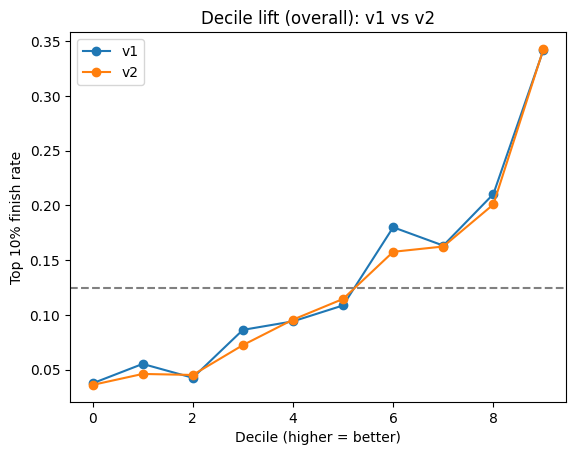

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(d1["decile"], d1["avg_top10pct_rate"], marker="o", label="v1")
plt.plot(d2["decile"], d2["avg_top10pct_rate"], marker="o", label="v2")
plt.axhline(BASELINE, linestyle="--", color="gray")
plt.xlabel("Decile (higher = better)")
plt.ylabel("Top 10% finish rate")
plt.title("Decile lift (overall): v1 vs v2")
plt.legend()
plt.show()

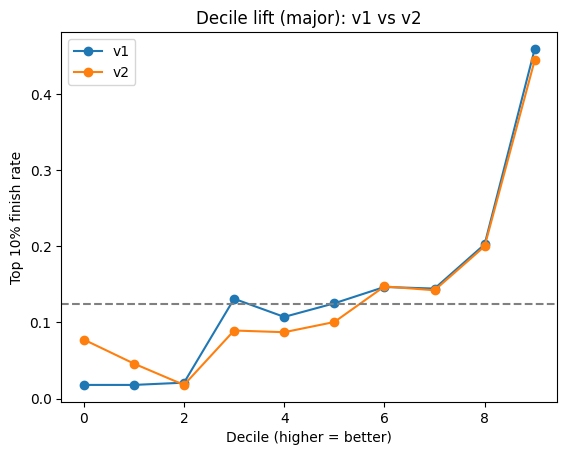

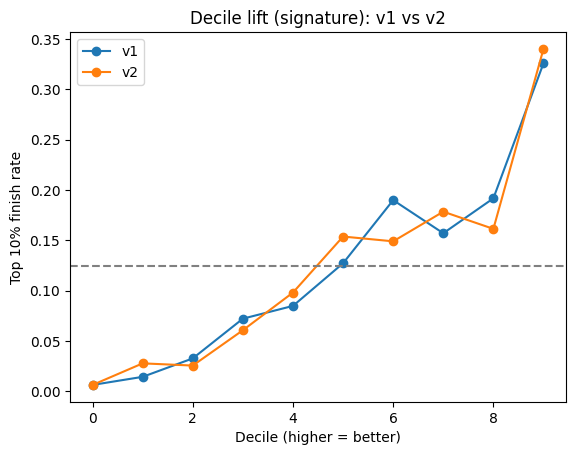

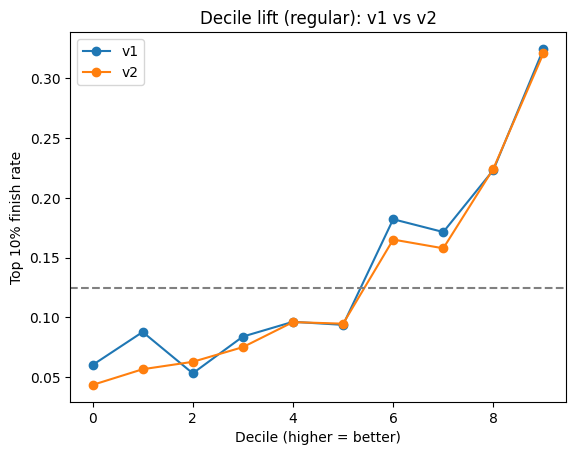

In [15]:
for t in tiers:
    sub = df[df["event_tier"] == t]
    a = decile_lift(sub, "oad_score_v1")
    b = decile_lift(sub, "oad_score_v2")

    plt.figure()
    if not a.empty:
        plt.plot(a["decile"], a["avg_top10pct_rate"], marker="o", label="v1")
    if not b.empty:
        plt.plot(b["decile"], b["avg_top10pct_rate"], marker="o", label="v2")

    plt.axhline(BASELINE, linestyle="--", color="gray")
    plt.xlabel("Decile (higher = better)")
    plt.ylabel("Top 10% finish rate")
    plt.title(f"Decile lift ({t}): v1 vs v2")
    plt.legend()
    plt.show()

In [16]:
def pick_hit_rate(df_in, score_col, k=3):
    hits = []
    n_events = 0
    for (yr, eid), g in df_in.groupby(["year", "event_id"]):
        g = g.dropna(subset=[score_col, "is_top10pct"]).sort_values(score_col, ascending=False)
        if len(g) == 0:
            continue
        n_events += 1
        hits.append(int(g.head(k)["is_top10pct"].max()))
    return (sum(hits) / len(hits)) if hits else np.nan, n_events

ks = [1, 3, 5]

rows = []
for t in ["all"] + tiers:
    sub = df if t == "all" else df[df["event_tier"] == t]
    for k in ks:
        v1, n = pick_hit_rate(sub, "oad_score_v1", k=k)
        v2, _ = pick_hit_rate(sub, "oad_score_v2", k=k)
        rows.append({"tier": t, "k": k, "v1_hit_rate": v1, "v2_hit_rate": v2, "n_events": n})

pick_summary = pd.DataFrame(rows).sort_values(["tier", "k"])
display(pick_summary)

,tier,k,v1_hit_rate,v2_hit_rate,n_events
0,all,1,0.580645,0.596774,62
1,all,3,0.854839,0.838710,62
2,all,5,0.951613,0.951613,62
3,major,1,0.875000,0.875000,8
4,major,3,1.000000,1.000000,8
5,major,5,1.000000,1.000000,8
9,regular,1,0.441176,0.441176,34
10,regular,3,0.794118,0.764706,34
11,regular,5,0.941176,0.941176,34
6,signature,1,0.700000,0.750000,20


In [17]:
def head_to_head(df_in, k=1):
    rows = []
    for (yr, eid), g in df_in.groupby(["year", "event_id"]):
        g = g.dropna(subset=["oad_score_v1", "oad_score_v2", "is_top10pct"]).copy()
        if g.empty:
            continue

        g1 = g.sort_values("oad_score_v1", ascending=False).head(k)
        g2 = g.sort_values("oad_score_v2", ascending=False).head(k)

        v1_hit = int(g1["is_top10pct"].max())
        v2_hit = int(g2["is_top10pct"].max())

        rows.append({"year": int(yr), "event_id": int(eid), "v1_hit": v1_hit, "v2_hit": v2_hit})

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    out["v2_better"] = (out["v2_hit"] > out["v1_hit"]).astype(int)
    out["v1_better"] = (out["v1_hit"] > out["v2_hit"]).astype(int)
    out["tie"] = (out["v1_hit"] == out["v2_hit"]).astype(int)
    return out

h2h = head_to_head(df, k=1)
display(h2h.head(20))

print("H2H totals:")
print("v2 better:", int(h2h["v2_better"].sum()))
print("v1 better:", int(h2h["v1_better"].sum()))
print("ties:", int(h2h["tie"].sum()))
print("n_events:", len(h2h))

,year,event_id,v1_hit,v2_hit,v2_better,v1_better,tie
0,2024,2,0,0,0,0,1
1,2024,3,1,1,0,0,1
2,2024,4,0,0,0,0,1
3,2024,5,0,1,1,0,0
4,2024,6,0,0,0,0,1
5,2024,7,0,0,0,0,1
6,2024,9,1,1,0,0,1
7,2024,10,0,0,0,0,1
8,2024,11,1,1,0,0,1
9,2024,12,1,1,0,0,1


H2H totals:
v2 better: 1
v1 better: 0
ties: 61
n_events: 62
